In [1]:
# Import relevant libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dabest
import NLCLIMB
from datetime import datetime
from pathlib import Path
import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

date = datetime.today().strftime('%Y%m%d')


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 17.61it/s]

Numba compilation complete!


## 1. Define Data Paths and Filters

In [2]:
# Data directories
acr_dir = Path(r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\DATA\Falling\Falling_ACR")
chrimson_dir = Path(r"D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\DATA\Falling\Falling_Chrimson2")

# Exclusion lists
ignore_folders = ['WT']
ignore_drivers = ['Th-Gal4', 'R58', 'R76B09']
ignore_responders = ['Tub_Tsh_Chrimson2', 'Tsh_Chrimson2', 'Tub_Tsh_ACR', 'Tsh_ACR']

print(f"ACR directory: {acr_dir}")
print(f"Chrimson2 directory: {chrimson_dir}")
print(f"\nIgnore folders: {ignore_folders}")
print(f"Ignore drivers: {ignore_drivers}")
print(f"Ignore responders: {ignore_responders}")

ACR directory: D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\DATA\Falling\Falling_ACR
Chrimson2 directory: D:\ACC Lab Dropbox\ACC Lab\Nicole Lee\DATA\Falling\Falling_Chrimson2

Ignore folders: ['WT']
Ignore drivers: ['Th-Gal4', 'R58', 'R76B09']
Ignore responders: ['Tub_Tsh_Chrimson2', 'Tsh_Chrimson2', 'Tub_Tsh_ACR', 'Tsh_ACR']


## 2. Helper Functions for Data Loading

In [3]:
def get_valid_cross_folders(base_dir, responder_type, ignore_folders, ignore_drivers, ignore_responders):
    """
    Get list of valid cross folders from a directory.
    
    Parameters:
    - base_dir: Path to the base directory (Falling_ACR or Falling_Chrimson2)
    - responder_type: 'ACR' or 'Chrimson2'
    - ignore_folders, ignore_drivers, ignore_responders: exclusion lists
    
    Returns:
    - List of (folder_path, driver_name, responder_name) tuples
    """
    valid_folders = []
    
    for folder in os.listdir(base_dir):
        folder_path = base_dir / folder
        
        # Skip if not a directory
        if not folder_path.is_dir():
            continue
            
        # Skip ignored folders
        if folder in ignore_folders:
            continue
            
        # Parse folder name (e.g., "MB319C x ACR")
        if ' x ' not in folder:
            continue
            
        parts = folder.split(' x ')
        if len(parts) != 2:
            continue
            
        driver_name = parts[0]
        responder_name = parts[1]
        
        # Skip ignored drivers and responders
        if driver_name in ignore_drivers:
            continue
        if responder_name in ignore_responders:
            continue
            
        # Only include folders matching the responder type
        if responder_type not in responder_name:
            continue
            
        valid_folders.append((folder_path, driver_name, responder_name))
    
    return valid_folders


def load_control_csv_files(folder_path, control_pattern):
    """
    Load all CSV files matching a control pattern from a folder.
    
    Parameters:
    - folder_path: Path to the cross folder
    - control_pattern: Pattern to match (e.g., 'w1118 x ACR' or 'w1118 x MB319C')
    
    Returns:
    - List of DataFrames
    """
    dfs = []
    
    for file in os.listdir(folder_path):
        if file.lower().endswith('.csv') and control_pattern in file:
            file_path = folder_path / file
            try:
                df = pd.read_csv(file_path)
                dfs.append(df)
            except Exception as e:
                print(f"  Error loading {file}: {e}")
    
    return dfs


def process_control_data(dfs, control_name):
    """
    Process raw CSV files into a combined DataFrame with calculated metrics.
    Uses NLCLIMB functions for processing.
    
    Parameters:
    - dfs: List of raw DataFrames
    - control_name: Name for the control (e.g., 'w1118')
    
    Returns:
    - Processed DataFrame ready for DABEST analysis, or None if processing fails
    """
    if len(dfs) == 0:
        return None
    
    try:
        # Determine FPS from first file
        lst = [df.Seconds.diff().mean() for df in dfs]
        fps = 5 if all(x < 0.8 for x in lst) else 1
        
        # Process files based on FPS
        if fps == 5:
            df_combined = NLCLIMB.fivefps(dfs, fps)
        else:
            df_combined = NLCLIMB.mixedfps(dfs, fps)
        
        # Clean up and add metadata
        df_combined = NLCLIMB.cleanup(df_combined, fps, control_name)
        
        # Generate derived metrics (speed, falls, pauses)
        df_processed = NLCLIMB.generation(df_combined, control_name)
        
        # Apply time rule (select specific time windows)
        df_final = NLCLIMB.timerule(df_processed)
        
        return df_final
    
    except Exception as e:
        print(f"  Error processing data: {e}")
        return None

## 3. Scan Directories and Collect Control Data

In [4]:
# Get valid cross folders from both directories
acr_folders = get_valid_cross_folders(acr_dir, 'ACR', ignore_folders, ignore_drivers, ignore_responders)
chrimson_folders = get_valid_cross_folders(chrimson_dir, 'Chrimson2', ignore_folders, ignore_drivers, ignore_responders)

print(f"Found {len(acr_folders)} valid ACR cross folders")
print(f"Found {len(chrimson_folders)} valid Chrimson2 cross folders")

# Display found folders
print("\n=== ACR Folders ===")
for folder_path, driver, responder in acr_folders[:10]:
    print(f"  {driver} x {responder}")
if len(acr_folders) > 10:
    print(f"  ... and {len(acr_folders) - 10} more")

print("\n=== Chrimson2 Folders ===")
for folder_path, driver, responder in chrimson_folders[:10]:
    print(f"  {driver} x {responder}")
if len(chrimson_folders) > 10:
    print(f"  ... and {len(chrimson_folders) - 10} more")

Found 45 valid ACR cross folders
Found 46 valid Chrimson2 cross folders

=== ACR Folders ===
  MB011B x ACR
  MB018B x ACR
  MB027B x ACR
  MB057B x ACR
  MB077B x ACR
  MB080C x ACR
  MB082C x ACR
  MB083C x ACR
  MB093C x ACR
  MB112C x ACR
  ... and 35 more

=== Chrimson2 Folders ===
  MB011B x Chrimson2
  MB018B x Chrimson2
  MB027B x Chrimson2
  MB057B x Chrimson2
  MB077B x Chrimson2
  MB080C x Chrimson2
  MB082C x Chrimson2
  MB083C x Chrimson2
  MB093C x Chrimson2
  MB112C x Chrimson2
  ... and 36 more


In [5]:
def collect_all_control_data(folders, responder_type):
    """
    Collect all control data from cross folders.
    
    For each cross folder:
    - Loads w1118 x [RESPONDER] files (responder/+ control)
    - Loads w1118 x [DRIVER] files (driver/+ control)
    
    Returns:
    - Dictionary with cross names as keys and control data as values
    """
    all_data = {}
    
    for folder_path, driver_name, responder_name in folders:
        cross_name = f"{driver_name} x {responder_name}"
        print(f"Processing: {cross_name}")
        
        # Define control patterns
        responder_ctrl_pattern = f"w1118 x {responder_type}"  # e.g., "w1118 x ACR"
        driver_ctrl_pattern = f"w1118 x {driver_name}"  # e.g., "w1118 x MB319C"
        
        # Load responder/+ control files
        resp_dfs = load_control_csv_files(folder_path, responder_ctrl_pattern)
        
        # Load driver/+ control files
        driver_dfs = load_control_csv_files(folder_path, driver_ctrl_pattern)
        
        # Check if we have both controls
        if len(resp_dfs) == 0:
            print(f"  Skipping: No responder/+ files found ({responder_ctrl_pattern})")
            continue
        if len(driver_dfs) == 0:
            print(f"  Skipping: No driver/+ files found ({driver_ctrl_pattern})")
            continue
        
        # Process control data
        print(f"  Found {len(resp_dfs)} responder/+ files and {len(driver_dfs)} driver/+ files")
        
        resp_processed = process_control_data(resp_dfs, 'w1118')
        driver_processed = process_control_data(driver_dfs, 'w1118')
        
        if resp_processed is None or driver_processed is None:
            print(f"  Skipping: Processing failed")
            continue
        
        all_data[cross_name] = {
            'responder_ctrl': resp_processed,
            'driver_ctrl': driver_processed,
            'driver_name': driver_name,
            'responder_name': responder_name,
            'n_responder_files': len(resp_dfs),
            'n_driver_files': len(driver_dfs)
        }
        print(f"  Success!")
    
    return all_data

In [6]:
# Collect ACR control data
print("="*60)
print("COLLECTING ACR CONTROL DATA")
print("="*60)
acr_data = collect_all_control_data(acr_folders, 'ACR')
print(f"\nSuccessfully processed {len(acr_data)} ACR crosses")

COLLECTING ACR CONTROL DATA
Processing: MB011B x ACR
  Found 8 responder/+ files and 8 driver/+ files
  Success!
Processing: MB018B x ACR
  Found 8 responder/+ files and 4 driver/+ files
  Success!
Processing: MB027B x ACR
  Found 8 responder/+ files and 6 driver/+ files
  Success!
Processing: MB057B x ACR
  Found 8 responder/+ files and 7 driver/+ files
  Success!
Processing: MB077B x ACR
  Found 8 responder/+ files and 5 driver/+ files
  Success!
Processing: MB080C x ACR
  Skipping: No driver/+ files found (w1118 x MB080C)
Processing: MB082C x ACR
  Found 8 responder/+ files and 2 driver/+ files
  Success!
Processing: MB083C x ACR
  Found 8 responder/+ files and 3 driver/+ files
  Success!
Processing: MB093C x ACR
  Found 8 responder/+ files and 3 driver/+ files
  Success!
Processing: MB112C x ACR
  Found 8 responder/+ files and 6 driver/+ files
  Success!
Processing: MB210B x ACR
  Found 8 responder/+ files and 4 driver/+ files
  Success!
Processing: MB242A x ACR
  Found 8 responder

In [7]:
# Collect Chrimson2 control data
print("="*60)
print("COLLECTING CHRIMSON2 CONTROL DATA")
print("="*60)
chrimson_data = collect_all_control_data(chrimson_folders, 'Chrimson2')
print(f"\nSuccessfully processed {len(chrimson_data)} Chrimson2 crosses")

COLLECTING CHRIMSON2 CONTROL DATA
Processing: MB011B x Chrimson2
  Found 6 responder/+ files and 8 driver/+ files
  Success!
Processing: MB018B x Chrimson2
  Found 6 responder/+ files and 4 driver/+ files
  Success!
Processing: MB027B x Chrimson2
  Found 6 responder/+ files and 8 driver/+ files
  Success!
Processing: MB057B x Chrimson2
  Found 6 responder/+ files and 5 driver/+ files
  Success!
Processing: MB077B x Chrimson2
  Found 6 responder/+ files and 5 driver/+ files
  Success!
Processing: MB080C x Chrimson2
  Found 6 responder/+ files and 4 driver/+ files
  Success!
Processing: MB082C x Chrimson2
  Found 6 responder/+ files and 4 driver/+ files
  Success!
Processing: MB083C x Chrimson2
  Found 6 responder/+ files and 4 driver/+ files
  Success!
Processing: MB093C x Chrimson2
  Found 11 responder/+ files and 3 driver/+ files
  Success!
Processing: MB112C x Chrimson2
  Found 11 responder/+ files and 5 driver/+ files
  Success!
Processing: MB210B x Chrimson2
  Found 11 responder/+ 

## 4. Calculate Bout Speed and Delta-Delta Analysis

In [8]:
def calculate_bout_speed_delta_delta(responder_ctrl_df, driver_ctrl_df, cross_name):
    """
    Calculate delta-delta for bout speed between responder/+ and driver/+ controls.
    
    Delta-delta analysis:
    - Group 1 (Responder/+): Full light - Dark = hedges g
    - Group 2 (Driver/+): Full light - Dark = hedges g
    - Delta-g: Group 2 hedges g - Group 1 hedges g
    
    Returns:
    - Dictionary with results or None if analysis fails
    """
    try:
        # Calculate bout speed for responder/+ control
        resp_boutspeed = NLCLIMB.boutspeed(responder_ctrl_df)
        resp_bspeed_df = NLCLIMB.velodabest(resp_boutspeed, "Responder", "BSpeed")
        
        # Calculate bout speed for driver/+ control
        driver_boutspeed = NLCLIMB.boutspeed(driver_ctrl_df)
        driver_bspeed_df = NLCLIMB.velodabest(driver_boutspeed, "Driver", "BSpeed")
        
        # Combine data for delta-delta analysis
        # Need to create a dataframe with: index, BSpeed, ExperimentState, Type
        resp_bspeed_df = resp_bspeed_df.reset_index(drop=False)
        resp_bspeed_df['Type'] = 'Responder'
        
        driver_bspeed_df = driver_bspeed_df.reset_index(drop=False)
        driver_bspeed_df['Type'] = 'Driver'
        
        # Combine
        combined_df = pd.concat([resp_bspeed_df, driver_bspeed_df], axis=0).reset_index(drop=True)
        combined_df['genre'] = combined_df['ExperimentState'] + " " + combined_df['Type']
        
        # Filter out Recovery phase
        combined_df = combined_df[combined_df['ExperimentState'] != 'Recovery'].copy()
        
        # Get sample sizes
        n_responder = len(resp_bspeed_df[resp_bspeed_df['ExperimentState'] == 'Dark']['index'].unique())
        n_driver = len(driver_bspeed_df[driver_bspeed_df['ExperimentState'] == 'Dark']['index'].unique())
        
        # Check for null values and remove
        name = []
        if any(combined_df['BSpeed'].isnull()):
            name = combined_df[combined_df['BSpeed'].isnull()]['index'].tolist()
        combined_df_clean = combined_df[~combined_df['index'].isin(name)]
        
        if len(combined_df_clean) < 8:  # Need at least 2 per group (4 groups)
            return None
        
        # Run DABEST delta-delta analysis
        # x1 = ExperimentState (Dark, Full)
        # experiment = Type (Responder, Driver)
        db = dabest.load(
            data=combined_df_clean,
            x=["ExperimentState", "Type"],
            y="BSpeed",
            delta2=True,
            experiment="Type",
            experiment_label=['Responder', 'Driver'],  # Responder first
            x1_level=["Dark", "Full"],
            paired="baseline",
            id_col="index"
        )
        
        # Get hedges g results
        results = db.hedges_g.results
        delta_delta_results = db.hedges_g.delta_delta.results
        
        # Parse results
        # Find which index is Responder vs Driver
        resp_idx = 0 if 'Responder' in str(results.control.iloc[0]) else 1
        driver_idx = 1 - resp_idx
        
        return {
            'cross_name': cross_name,
            'n_responder': n_responder,
            'n_driver': n_driver,
            'responder_hedges_g': results.difference.iloc[resp_idx],
            'responder_ci_low': results.bca_low.iloc[resp_idx],
            'responder_ci_high': results.bca_high.iloc[resp_idx],
            'driver_hedges_g': results.difference.iloc[driver_idx],
            'driver_ci_low': results.bca_low.iloc[driver_idx],
            'driver_ci_high': results.bca_high.iloc[driver_idx],
            'delta_delta': delta_delta_results.difference.iloc[0],
            'delta_delta_ci_low': delta_delta_results.bca_low.iloc[0],
            'delta_delta_ci_high': delta_delta_results.bca_high.iloc[0],
            'pvalue': delta_delta_results.pvalue_permutation.iloc[0] if 'pvalue_permutation' in delta_delta_results.columns else np.nan
        }
    
    except Exception as e:
        print(f"  Error in delta-delta analysis for {cross_name}: {e}")
        return None

In [9]:
# Run delta-delta analysis for ACR crosses
print("="*60)
print("DELTA-DELTA ANALYSIS: ACR CROSSES")
print("="*60)

acr_results = []
for cross_name, data in acr_data.items():
    print(f"Analyzing: {cross_name}")
    result = calculate_bout_speed_delta_delta(
        data['responder_ctrl'],
        data['driver_ctrl'],
        cross_name
    )
    if result:
        result['responder_type'] = 'ACR'
        acr_results.append(result)
        print(f"  Delta-delta: {result['delta_delta']:.3f} [{result['delta_delta_ci_low']:.3f}, {result['delta_delta_ci_high']:.3f}]")
    else:
        print(f"  Analysis failed")

print(f"\nSuccessfully analyzed {len(acr_results)} ACR crosses")

DELTA-DELTA ANALYSIS: ACR CROSSES
Analyzing: MB011B x ACR
  Delta-delta: -0.241 [-0.476, 0.006]
Analyzing: MB018B x ACR
  Delta-delta: -0.019 [-0.337, 0.300]
Analyzing: MB027B x ACR
  Delta-delta: -0.001 [-0.331, 0.325]
Analyzing: MB057B x ACR
  Delta-delta: -0.148 [-0.439, 0.127]
Analyzing: MB077B x ACR
  Delta-delta: -0.158 [-0.517, 0.185]
Analyzing: MB082C x ACR
  Delta-delta: -0.301 [-0.695, 0.104]
Analyzing: MB083C x ACR
  Delta-delta: -0.054 [-0.537, 0.474]
Analyzing: MB093C x ACR
  Delta-delta: -0.108 [-0.409, 0.209]
Analyzing: MB112C x ACR
  Delta-delta: -0.111 [-0.379, 0.160]
Analyzing: MB210B x ACR
  Delta-delta: -0.063 [-0.392, 0.275]
Analyzing: MB242A x ACR
  Delta-delta: 0.052 [-0.344, 0.433]
Analyzing: MB310C x ACR
  Delta-delta: 0.125 [-0.082, 0.470]
Analyzing: MB319C x ACR
  Delta-delta: -0.023 [-0.319, 0.315]
Analyzing: MB399B x ACR
  Delta-delta: -0.416 [-0.861, -0.058]
Analyzing: MB434B x ACR
  Delta-delta: -0.753 [-1.109, -0.406]
Analyzing: MB542B x ACR
  Delta-delt

In [10]:
# Run delta-delta analysis for Chrimson2 crosses
print("="*60)
print("DELTA-DELTA ANALYSIS: CHRIMSON2 CROSSES")
print("="*60)

chrimson_results = []
for cross_name, data in chrimson_data.items():
    print(f"Analyzing: {cross_name}")
    result = calculate_bout_speed_delta_delta(
        data['responder_ctrl'],
        data['driver_ctrl'],
        cross_name
    )
    if result:
        result['responder_type'] = 'Chrimson2'
        chrimson_results.append(result)
        print(f"  Delta-delta: {result['delta_delta']:.3f} [{result['delta_delta_ci_low']:.3f}, {result['delta_delta_ci_high']:.3f}]")
    else:
        print(f"  Analysis failed")

print(f"\nSuccessfully analyzed {len(chrimson_results)} Chrimson2 crosses")

DELTA-DELTA ANALYSIS: CHRIMSON2 CROSSES
Analyzing: MB011B x Chrimson2
  Delta-delta: 0.174 [-0.072, 0.433]
Analyzing: MB018B x Chrimson2
  Delta-delta: 0.511 [0.234, 0.783]
Analyzing: MB027B x Chrimson2
  Delta-delta: 0.277 [0.000, 0.535]
Analyzing: MB057B x Chrimson2
  Delta-delta: 0.206 [-0.130, 0.570]
Analyzing: MB077B x Chrimson2
  Delta-delta: 0.720 [0.378, 1.136]
Analyzing: MB080C x Chrimson2
  Delta-delta: 0.170 [-0.197, 0.551]
Analyzing: MB082C x Chrimson2
  Delta-delta: 0.219 [-0.075, 0.495]
Analyzing: MB083C x Chrimson2
  Delta-delta: 0.381 [-0.052, 0.764]
Analyzing: MB093C x Chrimson2
  Delta-delta: -0.328 [-0.800, 0.149]
Analyzing: MB112C x Chrimson2
  Delta-delta: 0.387 [0.078, 0.693]
Analyzing: MB210B x Chrimson2
  Delta-delta: -0.510 [-0.959, -0.109]
Analyzing: MB242A x Chrimson2
  Delta-delta: 0.432 [0.107, 0.839]
Analyzing: MB310C x Chrimson2
  Delta-delta: 0.023 [-0.253, 0.301]
Analyzing: MB319C x Chrimson2
  Delta-delta: 0.486 [0.185, 0.788]
Analyzing: MB323B x Chrim

## 5. Summary Tables

In [11]:
# Combine all results
all_results = acr_results + chrimson_results
df_results = pd.DataFrame(all_results)

if len(df_results) > 0:
    # Sort by delta-delta value
    df_results = df_results.sort_values('delta_delta').reset_index(drop=True)
    
    print(f"Total crosses analyzed: {len(df_results)}")
    print(f"  ACR: {len(acr_results)}")
    print(f"  Chrimson2: {len(chrimson_results)}")
else:
    print("No results to display")

Total crosses analyzed: 83
  ACR: 40
  Chrimson2: 43


In [12]:
# Display summary table
if len(df_results) > 0:
    # Create formatted summary table
    summary_table = df_results[[
        'cross_name', 'responder_type', 'n_responder', 'n_driver',
        'responder_hedges_g', 'driver_hedges_g', 'delta_delta',
        'delta_delta_ci_low', 'delta_delta_ci_high'
    ]].copy()
    
    # Round numeric columns
    numeric_cols = ['responder_hedges_g', 'driver_hedges_g', 'delta_delta', 
                    'delta_delta_ci_low', 'delta_delta_ci_high']
    summary_table[numeric_cols] = summary_table[numeric_cols].round(3)
    
    # Rename columns for clarity
    summary_table.columns = [
        'Cross', 'Responder', 'N (Resp/+)', 'N (Driver/+)',
        'Resp/+ Hedges g', 'Driver/+ Hedges g', 'Delta-g',
        '95% CI Low', '95% CI High'
    ]
    
    display(summary_table)
else:
    print("No results to display")

,Cross,Responder,N (Resp/+),N (Driver/+),Resp/+ Hedges g,Driver/+ Hedges g,Delta-g,95% CI Low,95% CI High
0,SS86947 x ACR,ACR,29,12,0.342,-0.457,-0.876,-1.779,-0.221
1,SS01298 x ACR,ACR,22,36,0.603,-0.107,-0.788,-1.387,-0.172
2,MB434B x ACR,ACR,126,49,0.403,-0.346,-0.753,-1.109,-0.406
3,SS77442 x ACR,ACR,22,56,0.603,-0.111,-0.627,-1.071,-0.200
4,SS77424 x ACR,ACR,126,55,0.391,-0.163,-0.556,-0.933,-0.142
...,...,...,...,...,...,...,...,...,...
78,MB018B x Chrimson2,Chrimson2,82,52,-0.027,0.468,0.511,0.234,0.783
79,SS80896 x Chrimson2,Chrimson2,28,56,-0.294,0.224,0.572,0.034,1.301
80,SS67662 x Chrimson2,Chrimson2,82,56,-0.029,0.544,0.647,0.283,1.072
81,SS80958 x Chrimson2,Chrimson2,28,27,-0.294,0.370,0.673,0.082,1.343


In [13]:
# Create detailed table with formatted CI strings
if len(df_results) > 0:
    detailed_table = df_results.copy()
    
    # Create formatted strings
    detailed_table['Responder/+ Effect'] = detailed_table.apply(
        lambda x: f"{x['responder_hedges_g']:.2f} [{x['responder_ci_low']:.2f}, {x['responder_ci_high']:.2f}]",
        axis=1
    )
    detailed_table['Driver/+ Effect'] = detailed_table.apply(
        lambda x: f"{x['driver_hedges_g']:.2f} [{x['driver_ci_low']:.2f}, {x['driver_ci_high']:.2f}]",
        axis=1
    )
    detailed_table['Delta-g [95% CI]'] = detailed_table.apply(
        lambda x: f"{x['delta_delta']:.2f} [{x['delta_delta_ci_low']:.2f}, {x['delta_delta_ci_high']:.2f}]",
        axis=1
    )
    
    # Select columns for display
    display_table = detailed_table[[
        'cross_name', 'responder_type', 'n_responder', 'n_driver',
        'Responder/+ Effect', 'Driver/+ Effect', 'Delta-g [95% CI]'
    ]].copy()
    
    display_table.columns = [
        'Cross', 'Responder Type', 'N (Resp/+)', 'N (Driver/+)',
        'Responder/+ Hedges g [95% CI]', 'Driver/+ Hedges g [95% CI]', 'Delta-g [95% CI]'
    ]
    
    print("\n=== Detailed Results Table ===")
    display(display_table)


=== Detailed Results Table ===


,Cross,Responder Type,N (Resp/+),N (Driver/+),Responder/+ Hedges g [95% CI],Driver/+ Hedges g [95% CI],Delta-g [95% CI]
0,SS86947 x ACR,ACR,29,12,"0.34 [0.03, 0.70]","-0.46 [-1.24, 0.03]","-0.88 [-1.78, -0.22]"
1,SS01298 x ACR,ACR,22,36,"0.60 [0.10, 1.11]","-0.11 [-0.43, 0.22]","-0.79 [-1.39, -0.17]"
2,MB434B x ACR,ACR,126,49,"0.40 [0.20, 0.60]","-0.35 [-0.63, -0.02]","-0.75 [-1.11, -0.41]"
3,SS77442 x ACR,ACR,22,56,"0.60 [0.10, 1.11]","-0.11 [-0.31, 0.09]","-0.63 [-1.07, -0.20]"
4,SS77424 x ACR,ACR,126,55,"0.39 [0.19, 0.59]","-0.16 [-0.44, 0.19]","-0.56 [-0.93, -0.14]"
...,...,...,...,...,...,...,...
78,MB018B x Chrimson2,Chrimson2,82,52,"-0.03 [-0.20, 0.16]","0.47 [0.24, 0.71]","0.51 [0.23, 0.78]"
79,SS80896 x Chrimson2,Chrimson2,28,56,"-0.29 [-0.71, 0.05]","0.22 [-0.11, 0.51]","0.57 [0.03, 1.30]"
80,SS67662 x Chrimson2,Chrimson2,82,56,"-0.03 [-0.21, 0.16]","0.54 [0.21, 0.80]","0.65 [0.28, 1.07]"
81,SS80958 x Chrimson2,Chrimson2,28,27,"-0.29 [-0.71, 0.05]","0.37 [-0.10, 0.86]","0.67 [0.08, 1.34]"


## 6. Visualization: Delta-g Forest Plot

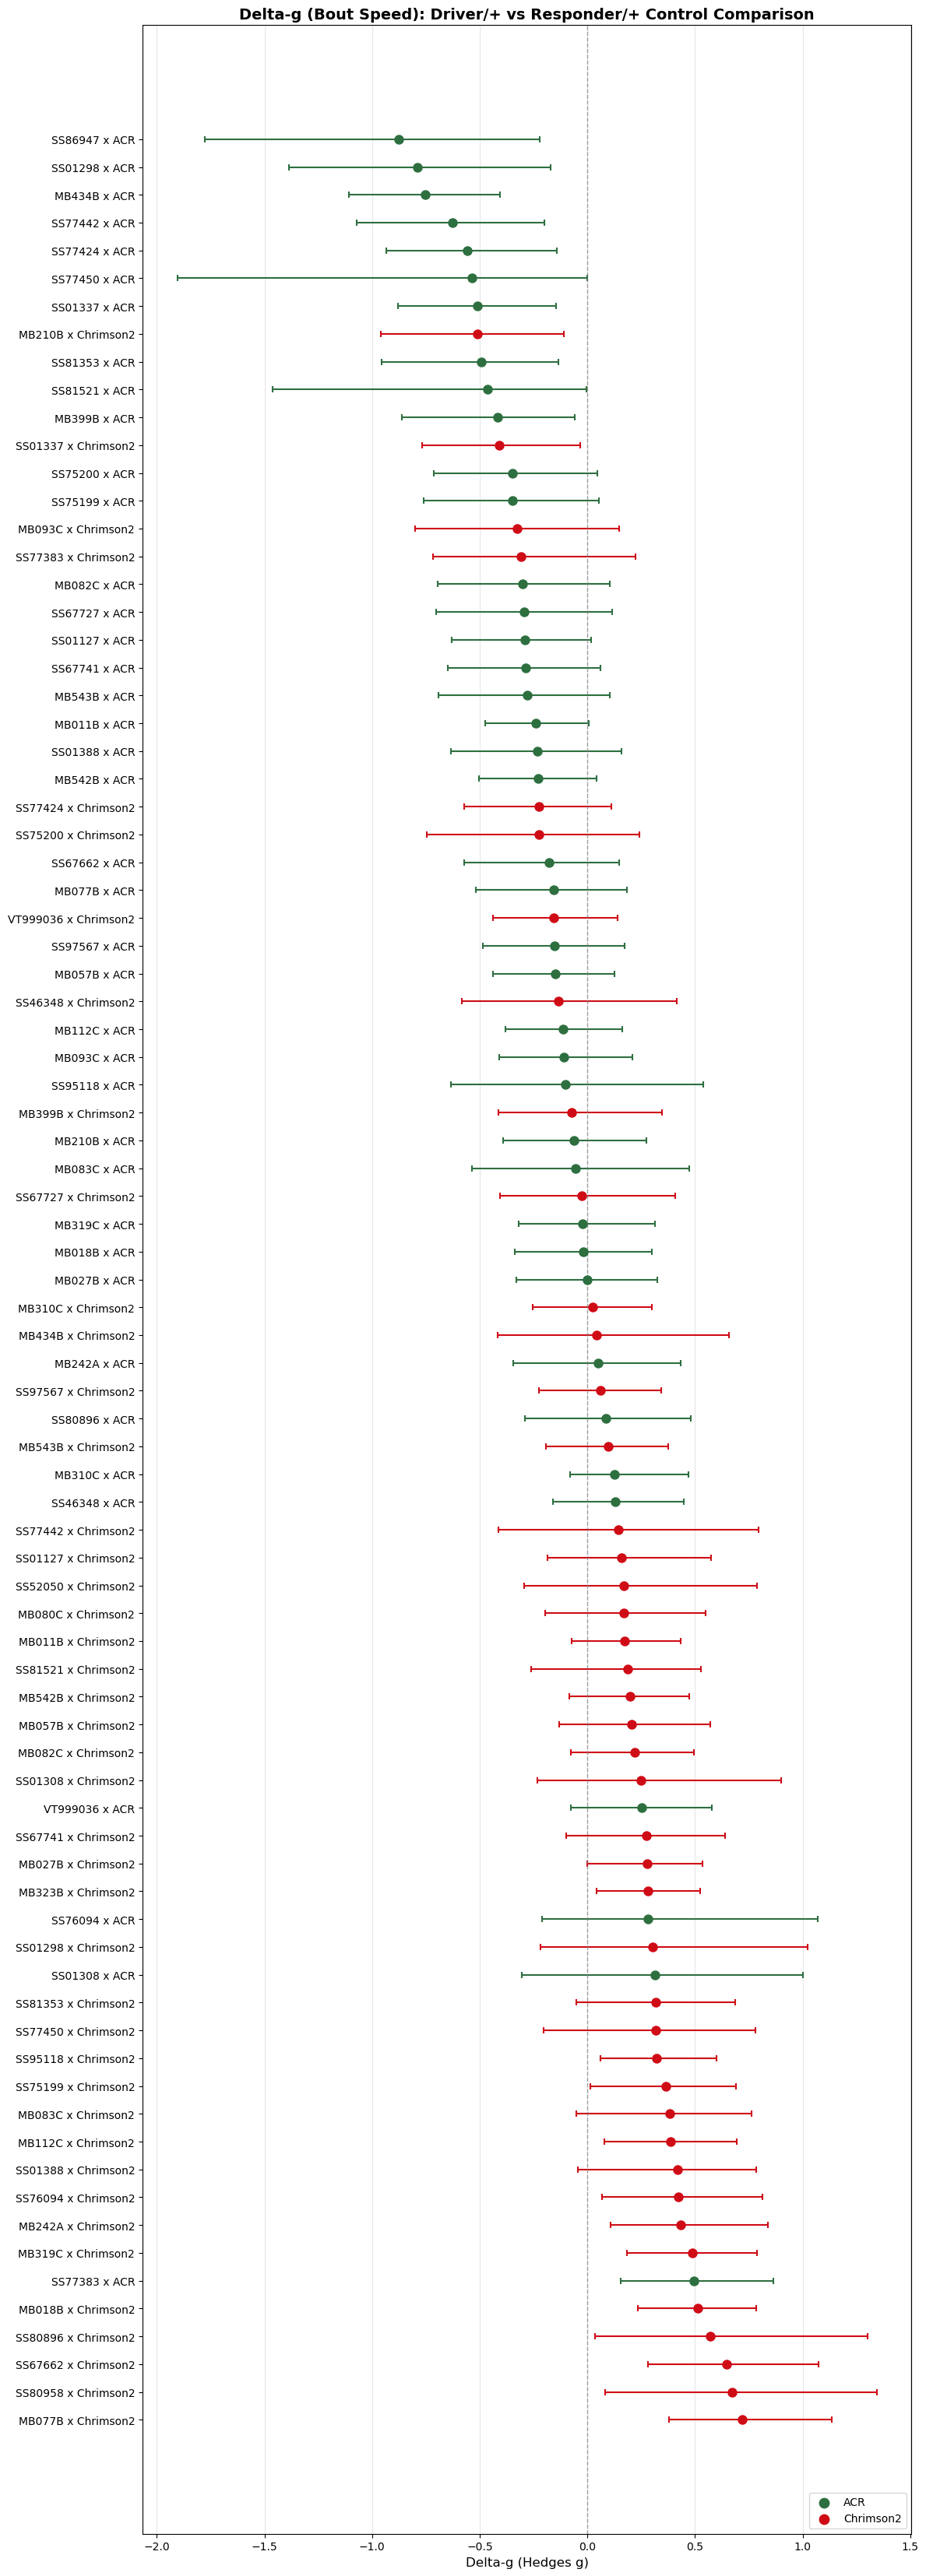

In [14]:
# Forest plot of delta-delta values
if len(df_results) > 0:
    # Sort by delta-delta
    df_plot = df_results.sort_values('delta_delta').reset_index(drop=True)
    
    # === CUSTOMIZABLE PARAMETERS ===
    fig_width = 12
    fig_height = max(len(df_plot) * 0.4, 8)
    
    # Colors
    acr_color = '#2e6f40'  # Green for ACR
    chrimson_color = '#cf0c16'  # Red for Chrimson2
    
    # Marker and error bar settings
    marker_size = 80
    ci_linewidth = 1.5
    ci_capsize = 3
    
    # Labels
    title = 'Delta-g (Bout Speed): Driver/+ vs Responder/+ Control Comparison'
    title_fontsize = 14
    xlabel = 'Delta-g (Hedges g)'
    xlabel_fontsize = 12
    ytick_fontsize = 10
    
    # Zero line
    zero_line_color = 'gray'
    zero_line_style = '--'
    # ================================
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    y_positions = np.arange(len(df_plot))
    
    # Plot each point with error bars
    for i, row in df_plot.iterrows():
        color = acr_color if row['responder_type'] == 'ACR' else chrimson_color
        
        # Calculate error bar values
        xerr_low = row['delta_delta'] - row['delta_delta_ci_low']
        xerr_high = row['delta_delta_ci_high'] - row['delta_delta']
        
        ax.errorbar(
            row['delta_delta'], i,
            xerr=[[xerr_low], [xerr_high]],
            fmt='o', markersize=8, color=color,
            elinewidth=ci_linewidth, capsize=ci_capsize, capthick=ci_linewidth
        )
    
    # Zero line
    ax.axvline(x=0, color=zero_line_color, linestyle=zero_line_style, linewidth=1, alpha=0.7)
    
    # Labels
    ax.set_yticks(y_positions)
    ax.set_yticklabels(df_plot['cross_name'], fontsize=ytick_fontsize)
    ax.set_xlabel(xlabel, fontsize=xlabel_fontsize)
    ax.set_title(title, fontsize=title_fontsize, fontweight='bold')
    
    # Grid
    ax.grid(axis='x', alpha=0.3)
    ax.set_axisbelow(True)
    
    # Legend
    ax.scatter([], [], color=acr_color, s=marker_size, label='ACR')
    ax.scatter([], [], color=chrimson_color, s=marker_size, label='Chrimson2')
    ax.legend(loc='lower right', fontsize=10)
    
    # Invert y-axis so largest values are at top
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
else:
    print("No results to plot")

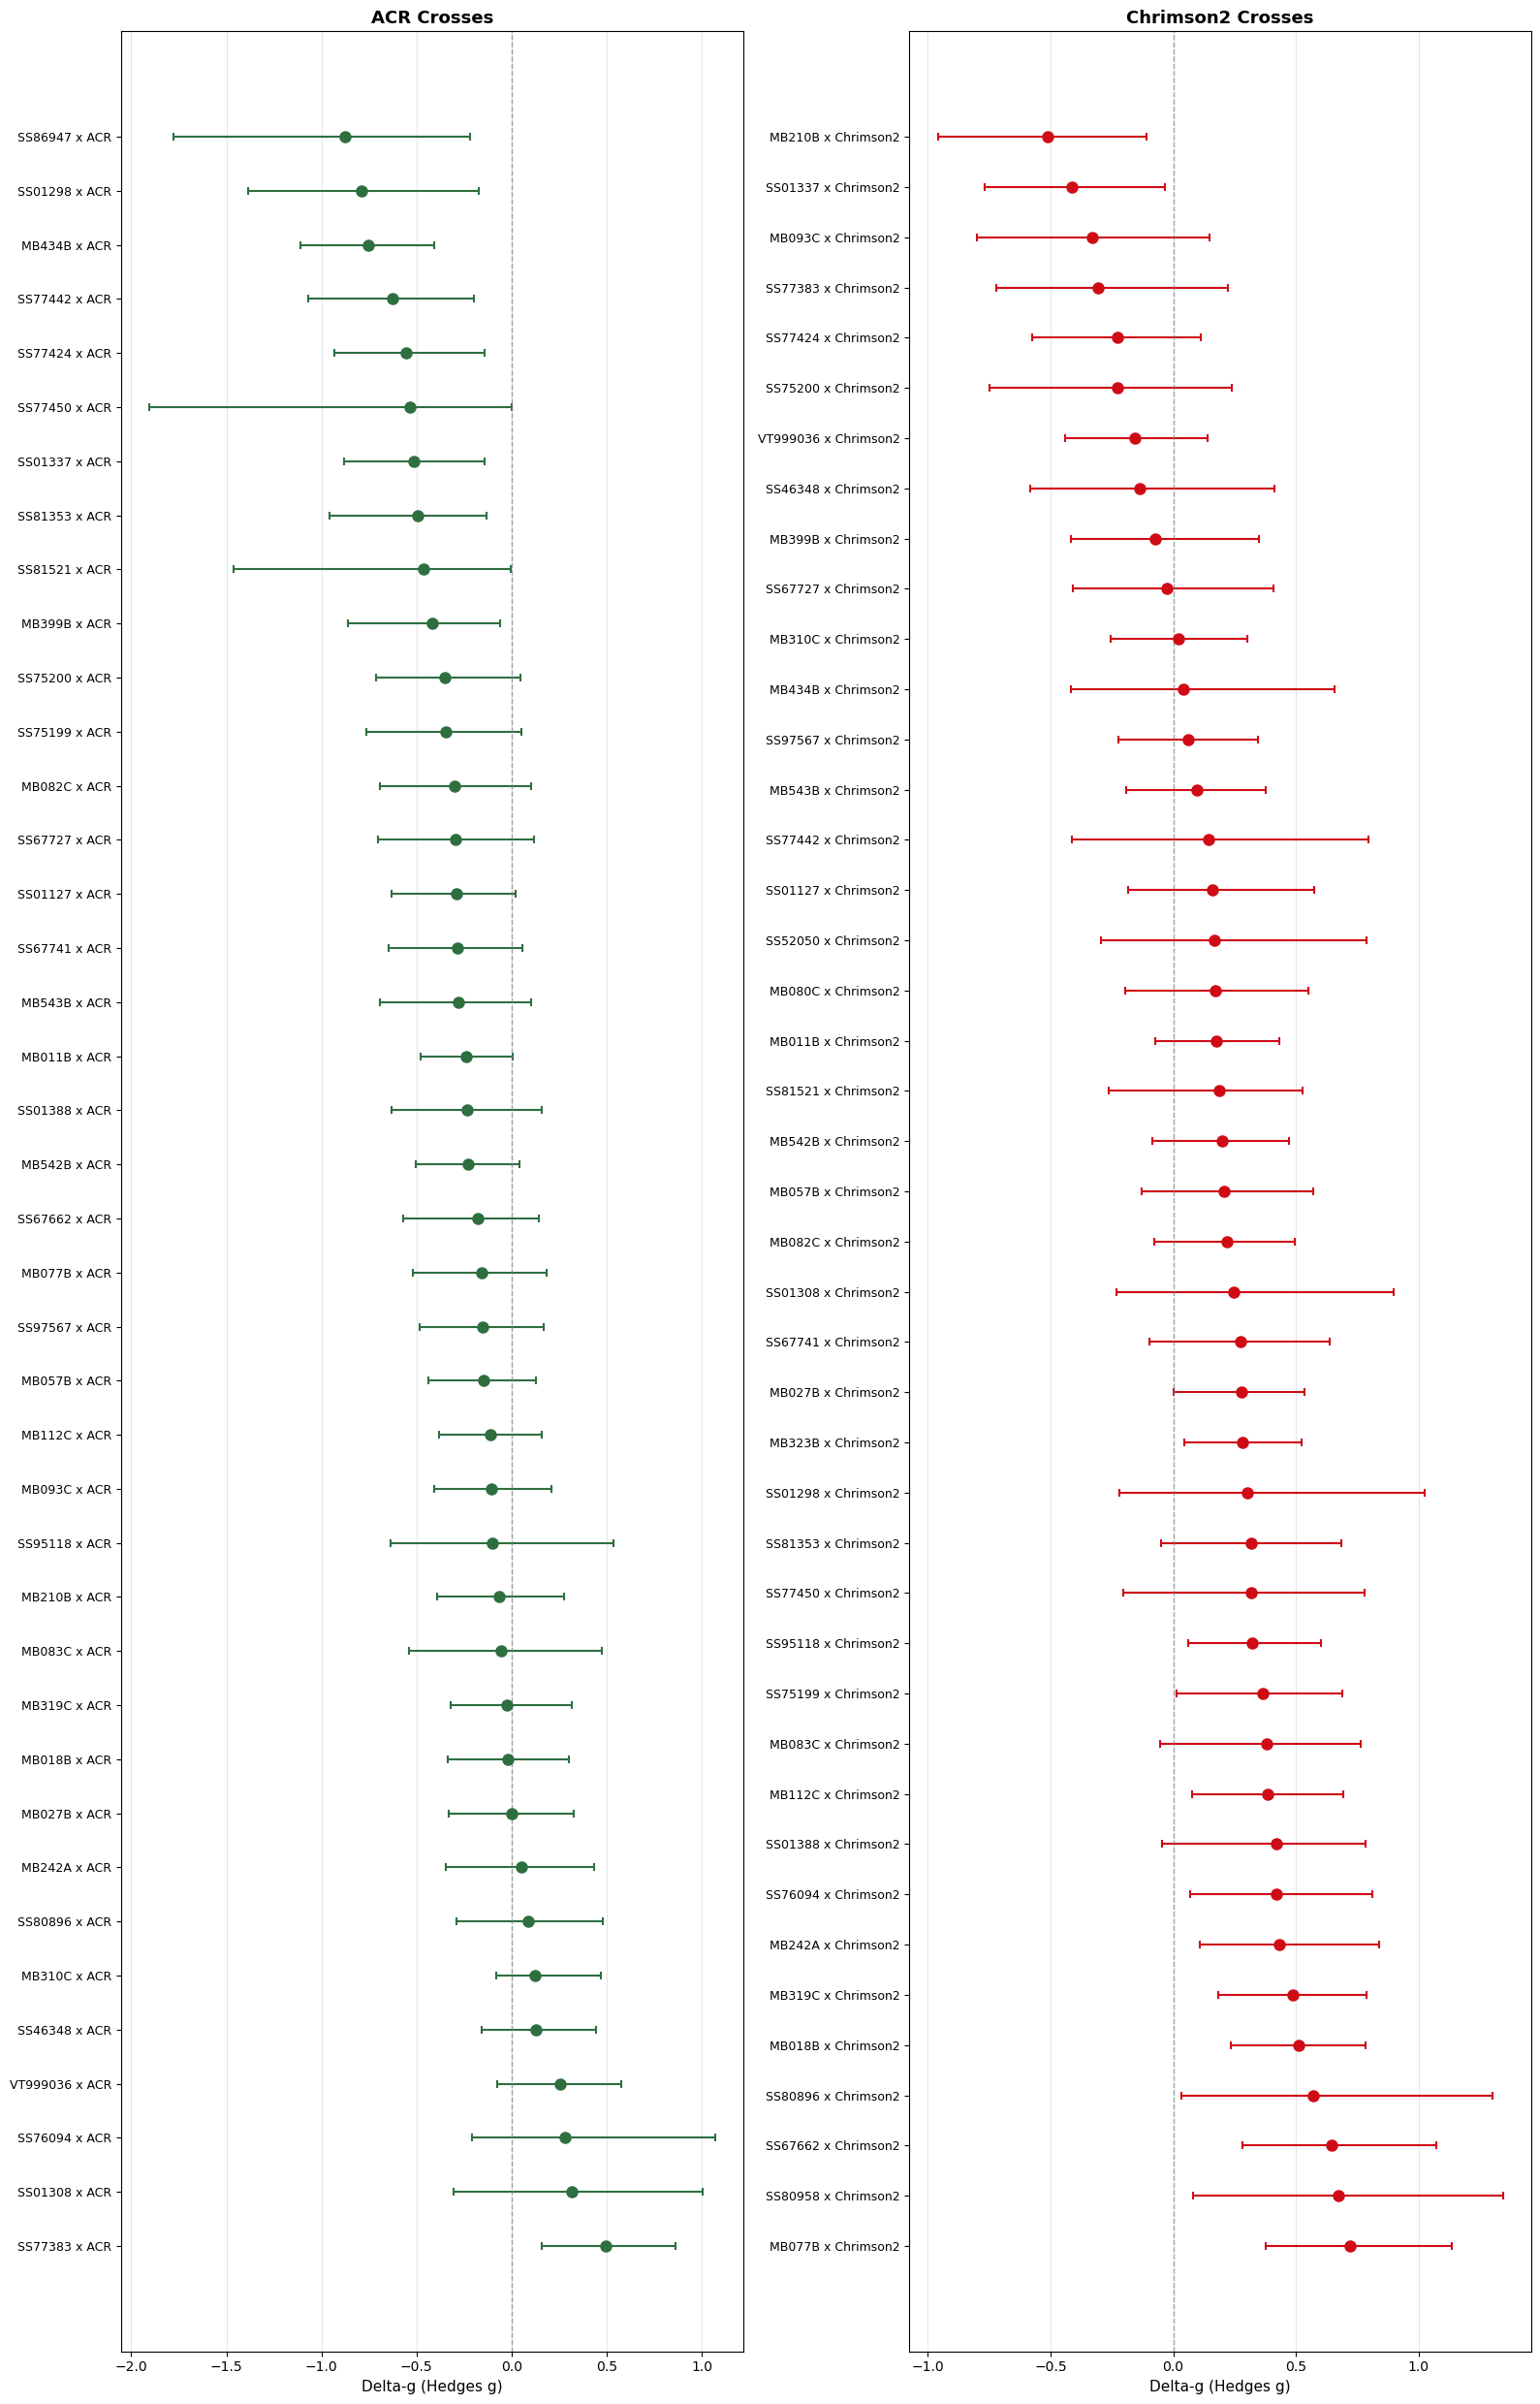

In [15]:
# Separate forest plots for ACR and Chrimson2
if len(df_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, max(len(df_results) * 0.3, 6)))
    
    # ACR subplot
    df_acr = df_results[df_results['responder_type'] == 'ACR'].sort_values('delta_delta').reset_index(drop=True)
    if len(df_acr) > 0:
        ax = axes[0]
        y_pos = np.arange(len(df_acr))
        
        for i, row in df_acr.iterrows():
            xerr_low = row['delta_delta'] - row['delta_delta_ci_low']
            xerr_high = row['delta_delta_ci_high'] - row['delta_delta']
            ax.errorbar(
                row['delta_delta'], i,
                xerr=[[xerr_low], [xerr_high]],
                fmt='o', markersize=8, color='#2e6f40',
                elinewidth=1.5, capsize=3, capthick=1.5
            )
        
        ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_acr['cross_name'], fontsize=9)
        ax.set_xlabel('Delta-g (Hedges g)', fontsize=11)
        ax.set_title('ACR Crosses', fontsize=13, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()
    else:
        axes[0].text(0.5, 0.5, 'No ACR data', ha='center', va='center')
    
    # Chrimson2 subplot
    df_chrim = df_results[df_results['responder_type'] == 'Chrimson2'].sort_values('delta_delta').reset_index(drop=True)
    if len(df_chrim) > 0:
        ax = axes[1]
        y_pos = np.arange(len(df_chrim))
        
        for i, row in df_chrim.iterrows():
            xerr_low = row['delta_delta'] - row['delta_delta_ci_low']
            xerr_high = row['delta_delta_ci_high'] - row['delta_delta']
            ax.errorbar(
                row['delta_delta'], i,
                xerr=[[xerr_low], [xerr_high]],
                fmt='o', markersize=8, color='#cf0c16',
                elinewidth=1.5, capsize=3, capthick=1.5
            )
        
        ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(df_chrim['cross_name'], fontsize=9)
        ax.set_xlabel('Delta-g (Hedges g)', fontsize=11)
        ax.set_title('Chrimson2 Crosses', fontsize=13, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
        ax.invert_yaxis()
    else:
        axes[1].text(0.5, 0.5, 'No Chrimson2 data', ha='center', va='center')
    
    plt.tight_layout()
    plt.show()

## 7. N Count Summary Table

In [16]:
# Create N count summary
if len(df_results) > 0:
    n_summary = df_results[['cross_name', 'responder_type', 'n_responder', 'n_driver']].copy()
    n_summary['Total N'] = n_summary['n_responder'] + n_summary['n_driver']
    n_summary.columns = ['Cross', 'Responder Type', 'N (Responder/+)', 'N (Driver/+)', 'Total N']
    
    print("=== Sample Size Summary ===")
    print(f"\nTotal crosses: {len(n_summary)}")
    print(f"Total responder/+ flies: {n_summary['N (Responder/+)'].sum()}")
    print(f"Total driver/+ flies: {n_summary['N (Driver/+)'].sum()}")
    print(f"\nMean responder/+ N per cross: {n_summary['N (Responder/+)'].mean():.1f}")
    print(f"Mean driver/+ N per cross: {n_summary['N (Driver/+)'].mean():.1f}")
    
    print("\n=== N Count Table ===")
    display(n_summary)

=== Sample Size Summary ===

Total crosses: 83
Total responder/+ flies: 8156
Total driver/+ flies: 4261

Mean responder/+ N per cross: 98.3
Mean driver/+ N per cross: 51.3

=== N Count Table ===


,Cross,Responder Type,N (Responder/+),N (Driver/+),Total N
0,SS86947 x ACR,ACR,29,12,41
1,SS01298 x ACR,ACR,22,36,58
2,MB434B x ACR,ACR,126,49,175
3,SS77442 x ACR,ACR,22,56,78
4,SS77424 x ACR,ACR,126,55,181
...,...,...,...,...,...
78,MB018B x Chrimson2,Chrimson2,82,52,134
79,SS80896 x Chrimson2,Chrimson2,28,56,84
80,SS67662 x Chrimson2,Chrimson2,82,56,138
81,SS80958 x Chrimson2,Chrimson2,28,27,55


In [19]:
print(n_summary.to_string())

                   Cross Responder Type  N (Responder/+)  N (Driver/+)  Total N
0          SS86947 x ACR            ACR               29            12       41
1          SS01298 x ACR            ACR               22            36       58
2           MB434B x ACR            ACR              126            49      175
3          SS77442 x ACR            ACR               22            56       78
4          SS77424 x ACR            ACR              126            55      181
5          SS77450 x ACR            ACR              126            40      166
6          SS01337 x ACR            ACR              126            63      189
7     MB210B x Chrimson2      Chrimson2              128            17      145
8          SS81353 x ACR            ACR              126            69      195
9          SS81521 x ACR            ACR              126            50      176
10          MB399B x ACR            ACR              126            17      143
11   SS01337 x Chrimson2      Chrimson2 

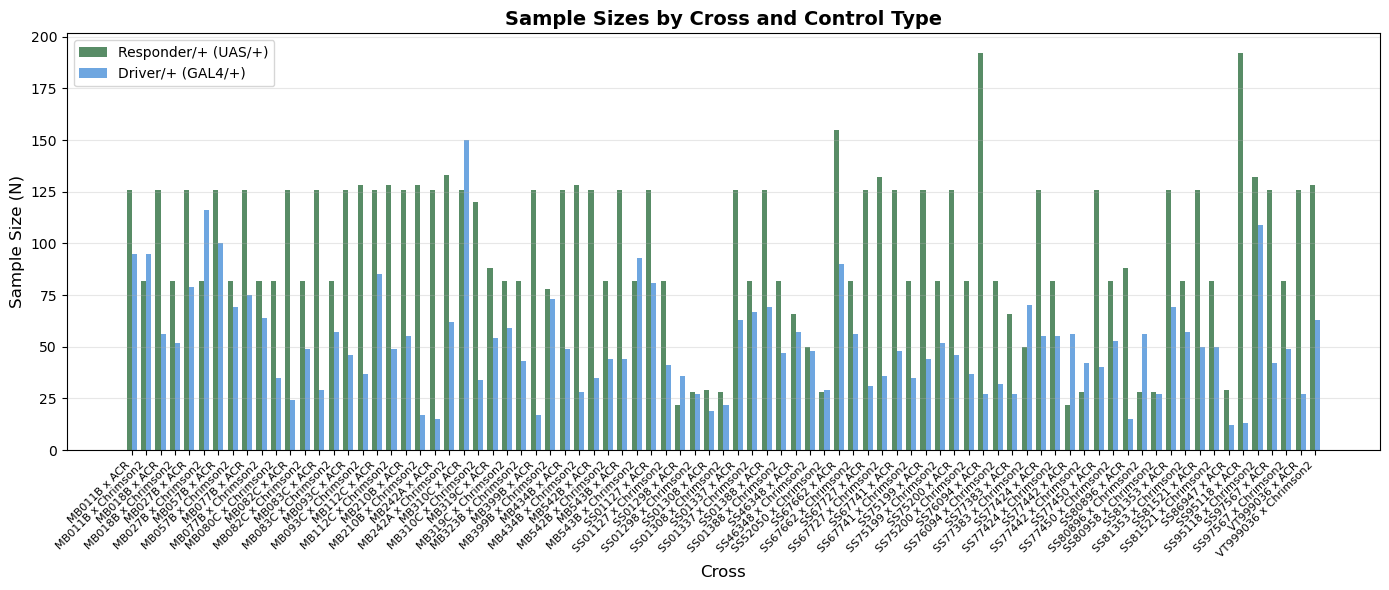

In [17]:
# Bar chart of sample sizes
if len(df_results) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    x = np.arange(len(df_results))
    width = 0.35
    
    # Sort by cross name for consistent display
    df_sorted = df_results.sort_values('cross_name').reset_index(drop=True)
    
    bars1 = ax.bar(x - width/2, df_sorted['n_responder'], width, label='Responder/+ (UAS/+)', color='#2e6f40', alpha=0.8)
    bars2 = ax.bar(x + width/2, df_sorted['n_driver'], width, label='Driver/+ (GAL4/+)', color='#4a90d9', alpha=0.8)
    
    ax.set_xlabel('Cross', fontsize=12)
    ax.set_ylabel('Sample Size (N)', fontsize=12)
    ax.set_title('Sample Sizes by Cross and Control Type', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_sorted['cross_name'], rotation=45, ha='right', fontsize=8)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()